Questo è il Notebook relativo alla task 4 del progetto.

In [9]:
#Librerie
import numpy as np
from scipy.sparse import csc_matrix, coo_matrix
from scipy.sparse.linalg import spsolve_triangular
from sksparse.cholmod import cholesky
import time

#funzione che legge le matrici in formato COO e restituisce la matrice in formato CSC
def read_coo_to_csc(a_filename):
    # Caricamento di A e conversione in CSC
    data_A = np.loadtxt(a_filename)
    rows = data_A[:, 0].astype(int)
    cols = data_A[:, 1].astype(int)
    vals = data_A[:, 2]
    A_coo = coo_matrix((vals, (rows, cols)))
    A_csc = A_coo.tocsc()
    return A_csc

A_orig_CSC = read_coo_to_csc("A_orig.txt")
A_reordered_CSC = read_coo_to_csc("A_reordered.txt")

print("=== MATRICE ORIGINALE ===")
print(f"Dimensione : {A_orig_CSC.shape}") #mi dice la dimensione della matrice n x m
print(f"NNZ        : {A_orig_CSC.nnz}\n") #mi dice il numero di elementi non nulli

print("=== MATRICE RIORDINATA ===")
print(f"Dimensione : {A_reordered_CSC.shape}")
print(f"NNZ        : {A_reordered_CSC.nnz}\n")

A_orig = -A_orig_CSC #rendo la matrice definita positiva
A_reordered = -A_reordered_CSC #rendo la matrice definita positiva

#funzione che calcola la fattorizzazione di Cholesky di una matrice
def my_cholesky(A):
    try:
        factor = cholesky(A, order="natural")
    except TypeError:
        try:
            factor = cholesky(A, ordering_method="natural")
        except TypeError:
            factor = cholesky(A)

    # 'factor' e' una TUPLA, quindi usiamo [0]
    R = csc_matrix(factor[0])
    return R.T.tocsc() #restituisce la matrice triangolare inferiore L in formato CSC

#calcolo fattorizzazione e tempo
t0 = time.perf_counter()
L_orig = my_cholesky(A_orig)
t_fact_orig = time.perf_counter() - t0

t0 = time.perf_counter()
L_reordered = my_cholesky(A_reordered)
t_fact_reord = time.perf_counter() - t0

#funzione che legge il termine noto b
def read_rhs(rhs_filename):
    data = np.loadtxt(rhs_filename)
    return data

b_orig = read_rhs("rhs_orig.txt")
b_reordered = read_rhs("rhs_reordered.txt")

#funzione che risolve il sistema lineare Ax = b usando la fattorizzazione di Cholesky
def solve_cholesky(L, b):
    # Risolvo Ly = b
    y = spsolve_triangular(L, -b, lower=True)
    # Risolvo L^Tu = y
    u = spsolve_triangular(L.T.tocsc(), y, lower=False)
    return u

# Calcolo delle soluzioni e tempo
t0 = time.perf_counter()
u_orig = solve_cholesky(L_orig, b_orig)
t_solve_orig = time.perf_counter() - t0

t0 = time.perf_counter()
u_reordered = solve_cholesky(L_reordered, b_reordered)
t_solve_reord = time.perf_counter() - t0



# Stampa dei risultati 
print("=== SISTEMA ORIGINALE ===")
print(f"Fill-in NNZ(L)   : {L_orig.nnz}\n")

print("=== SISTEMA RIORDINATO ===")
print(f"Fill-in NNZ(L)   : {L_reordered.nnz}\n")

#ATTENZIONE: i valori di u_orig e u_reordered sono gli stessi, ma l'ordine degli elementi è diverso. In totale ho N^2 elementi
print("Primi 10 elementi della soluzione:", u_orig[:10])
print("Primi 10 elementi della soluzione riordinata:", u_reordered[:10])


# --- SISTEMA ORIGINALE ---
#  Tempo di fattorizzazione
t0 = time.perf_counter()
L_orig = my_cholesky(A_orig)
t_fact_orig = time.perf_counter() - t0

#  Tempo di risoluzione dei sistemi triangolari
t0 = time.perf_counter()
u_orig = solve_cholesky(L_orig, b_orig)
t_solve_orig = time.perf_counter() - t0

# --- SISTEMA RIORDINATO ---
t0 = time.perf_counter()
L_reordered = my_cholesky(A_reordered)
t_fact_reord = time.perf_counter() - t0

t0 = time.perf_counter()
u_reordered = solve_cholesky(L_reordered, b_reordered)
t_solve_reord = time.perf_counter() - t0

print("=== PRESTAZIONI (TEMPI IN SECONDI) ===")
print(f"Originale  -> Fattorizzazione: {t_fact_orig:.6f} s | Soluzione: {t_solve_orig:.6f} s | Totale: {t_fact_orig + t_solve_orig:.6f} s")
print(f"Riordinato -> Fattorizzazione: {t_fact_reord:.6f} s | Soluzione: {t_solve_reord:.6f} s | Totale: {t_fact_reord + t_solve_reord:.6f} s")
print(f"Speedup Fattorizzazione: {t_fact_orig / t_fact_reord:.2f}x")


=== MATRICE ORIGINALE ===
Dimensione : (65536, 65536)
NNZ        : 326656

=== MATRICE RIORDINATA ===
Dimensione : (65536, 65536)
NNZ        : 326656

=== SISTEMA ORIGINALE ===
Fill-in NNZ(L)   : 16777471

=== SISTEMA RIORDINATO ===
Fill-in NNZ(L)   : 2318974

Primi 10 elementi della soluzione: [0.00379557 0.00683436 0.00941562 0.01168009 0.01370483 0.01553736
 0.01720962 0.01874453 0.02015929 0.02146733]
Primi 10 elementi della soluzione riordinata: [0.00379557 0.00683436 0.00683436 0.01261337 0.01168009 0.02208976
 0.00941562 0.01763628 0.01168009 0.02208976]
=== PRESTAZIONI (TEMPI IN SECONDI) ===
Originale  -> Fattorizzazione: 1.744644 s | Soluzione: 2.669742 s | Totale: 4.414387 s
Riordinato -> Fattorizzazione: 0.408853 s | Soluzione: 0.315327 s | Totale: 0.724181 s
Speedup Fattorizzazione: 4.27x


Arrivati a questo punto non ci resta che da produrre i grafici delle soluzioni

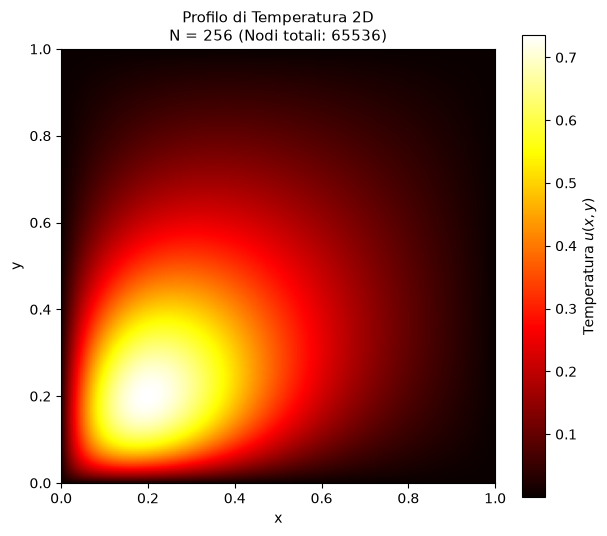

In [10]:
import matplotlib.pyplot as plt
import numpy as np


def plot_solution_2d(u, N=None, title="Profilo di Temperatura 2D"):
    # Se N non viene fornito esplicitamente, lo calcoliamo dalla lunghezza del vettore u
    if N is None:
        N = int(np.sqrt(len(u)))

    nodi_totali = N * N

    # Reshape del vettore 1D nella griglia 2D NxN
    U_grid = u.reshape((N, N), order="F") # in questo modo, la griglia viene riempita colonna per colonna, che è coerente con l'ordine di memorizzazione dei dati .

    plt.figure(figsize=(7, 6))

    # Mappa di calore 2D (imshow)
    im = plt.imshow(U_grid, cmap="hot", origin="lower", extent=[0, 1, 0, 1])

    plt.colorbar(im, label="Temperatura $u(x,y)$")

    # Titolo con Profilo di Temperatura 2D, N e Nodi Totali
    plt.title(
        f"{title}\nN = {N} (Nodi totali: {nodi_totali})",
        fontsize=11,
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(False)
    plt.show()

#plot per il sistema orginale
plot_solution_2d(u_orig, title="Profilo di Temperatura 2D")

